In [11]:
# imports
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time

# Scraper setup

In [12]:
# need this so basketball reference doesnt block us
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36',
}

def get_soup(url):
    r = requests.get(url, headers=HEADERS, timeout=20)
    
    # basketball reference hides some tables in html comments so we gotta unwrap them
    html = r.text.replace('<!--', '').replace('-->', '')
    
    time.sleep(3)  # wait 3 seconds between requests so we dont get blocked
    
    return BeautifulSoup(html, 'lxml')

# Scrape team stats

In [13]:
def get_playoff_stats(team_abbr):
    url = 'https://www.basketball-reference.com/teams/' + team_abbr + '/2026.html'
    soup = get_soup(url)
    
    table = soup.find('table', {'id': 'per_game_stats_post'})
    df = pd.read_html(str(table))[0]
    
    # drop repeated header rows
    df = df[df['Rk'] != 'Rk'].reset_index(drop=True)
    
    # last row is team totals
    team_row = df.iloc[-1]
    
    stats = {
        'post_pts':    team_row['PTS'],
        'post_reb':    team_row['TRB'],
        'post_ast':    team_row['AST'],
        'post_tov':    team_row['TOV'],
        'post_fg_pct': team_row['FG%'],
        'post_3p_pct': team_row['3P%'],
    }
    
    return stats

sas_post = get_playoff_stats('SAS')
nyk_post = get_playoff_stats('NYK')

# merge into main dicts
sas.update(sas_post)
nyk.update(nyk_post)

# display nicely
df_display = pd.DataFrame([sas, nyk]).set_index('team').T
print(df_display)

/var/folders/gb/0p82yghn3xn2r19wldcw11gc0000gn/T/ipykernel_64724/302846114.py:6: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]


team                SAS      NYK
ortg         119.600000  119.800
drtg         111.300000  113.300
net_rtg        8.300000    6.500
pace          99.900000   96.800
efg_pct        0.559000    0.557
tov_pct       11.800000   12.100
orb_pct       26.200000   29.300
ft_rate        0.215000    0.188
def_efg_pct    0.522000    0.541
def_tov_pct   11.500000   13.100
def_ft_rate    0.180000    0.206
post_pts     115.300000  119.900
post_reb      47.300000   45.100
post_ast      25.100000   26.700
post_tov      15.200000   13.600
post_fg_pct    0.469000    0.515
post_3p_pct    0.365000    0.400
top_bpm       10.700000    3.500
avg_bpm        1.945455    1.200
total_vorp    38.500000   34.600
top_per       29.900000   22.000


/var/folders/gb/0p82yghn3xn2r19wldcw11gc0000gn/T/ipykernel_64724/302846114.py:6: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]


# Playoff stats

In [14]:
def get_all_stats(team_abbr):
    url = 'https://www.basketball-reference.com/teams/' + team_abbr + '/2026.html'
    soup = get_soup(url)
    
    stats = {'team': team_abbr}
    
    # --- regular season advanced stats ---
    table = soup.find('table', {'id': 'team_misc'})
    df = pd.read_html(str(table))[0]
    df.columns = [' '.join(col).strip() for col in df.columns]
    team_row = df.iloc[0]
    
    stats['ortg']        = team_row['Unnamed: 8_level_0 ORtg']
    stats['drtg']        = team_row['Unnamed: 9_level_0 DRtg']
    stats['net_rtg']     = stats['ortg'] - stats['drtg']
    stats['pace']        = team_row['Unnamed: 10_level_0 Pace']
    stats['efg_pct']     = team_row['Offense Four Factors eFG%']
    stats['tov_pct']     = team_row['Offense Four Factors TOV%']
    stats['orb_pct']     = team_row['Offense Four Factors ORB%']
    stats['ft_rate']     = team_row['Offense Four Factors FT/FGA']
    stats['def_efg_pct'] = team_row['Defense Four Factors eFG%']
    stats['def_tov_pct'] = team_row['Defense Four Factors TOV%']
    stats['def_ft_rate'] = team_row['Defense Four Factors FT/FGA']
    
    # --- playoff stats ---
    table = soup.find('table', {'id': 'per_game_stats_post'})
    df = pd.read_html(str(table))[0]
    df = df[df['Rk'] != 'Rk'].reset_index(drop=True)
    team_row = df.iloc[-1]
    
    stats['post_pts']    = team_row['PTS']
    stats['post_reb']    = team_row['TRB']
    stats['post_ast']    = team_row['AST']
    stats['post_tov']    = team_row['TOV']
    stats['post_fg_pct'] = team_row['FG%']
    stats['post_3p_pct'] = team_row['3P%']
    
    # --- player impact ---
    table = soup.find('table', {'id': 'advanced'})
    df = pd.read_html(str(table))[0]
    df = df[df['Rk'] != 'Rk'].reset_index(drop=True)
    df['MP']   = pd.to_numeric(df['MP'],   errors='coerce')
    df['BPM']  = pd.to_numeric(df['BPM'],  errors='coerce')
    df['VORP'] = pd.to_numeric(df['VORP'], errors='coerce')
    df['PER']  = pd.to_numeric(df['PER'],  errors='coerce')
    df = df[df['MP'] > 500]
    
    stats['top_bpm']    = df['BPM'].max()
    stats['avg_bpm']    = df['BPM'].mean()
    stats['total_vorp'] = df['VORP'].sum()
    stats['top_per']    = df['PER'].max()
    
    return stats

sas = get_all_stats('SAS')
nyk = get_all_stats('NYK')

df_display = pd.DataFrame([sas, nyk]).set_index('team').T
print(df_display)

/var/folders/gb/0p82yghn3xn2r19wldcw11gc0000gn/T/ipykernel_64724/1263189791.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]
/var/folders/gb/0p82yghn3xn2r19wldcw11gc0000gn/T/ipykernel_64724/1263189791.py:27: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]
/var/folders/gb/0p82yghn3xn2r19wldcw11gc0000gn/T/ipykernel_64724/1263189791.py:40: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]


team                SAS      NYK
ortg         119.600000  119.800
drtg         111.300000  113.300
net_rtg        8.300000    6.500
pace          99.900000   96.800
efg_pct        0.559000    0.557
tov_pct       11.800000   12.100
orb_pct       26.200000   29.300
ft_rate        0.215000    0.188
def_efg_pct    0.522000    0.541
def_tov_pct   11.500000   13.100
def_ft_rate    0.180000    0.206
post_pts     115.300000  119.900
post_reb      47.300000   45.100
post_ast      25.100000   26.700
post_tov      15.200000   13.600
post_fg_pct    0.469000    0.515
post_3p_pct    0.365000    0.400
top_bpm       10.700000    3.500
avg_bpm        1.945455    1.200
total_vorp    38.500000   34.600
top_per       29.900000   22.000


/var/folders/gb/0p82yghn3xn2r19wldcw11gc0000gn/T/ipykernel_64724/1263189791.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]
/var/folders/gb/0p82yghn3xn2r19wldcw11gc0000gn/T/ipykernel_64724/1263189791.py:27: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]
/var/folders/gb/0p82yghn3xn2r19wldcw11gc0000gn/T/ipykernel_64724/1263189791.py:40: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]


# Scoring each stat and calculating win probability

In [15]:
sas_points = 0
nyk_points = 0

# stats where higher is better
higher_is_better = ['ortg', 'net_rtg', 'efg_pct', 'orb_pct', 'ft_rate',
                    'def_tov_pct', 'post_pts', 'post_reb', 'post_ast',
                    'post_fg_pct', 'post_3p_pct', 'top_bpm', 'avg_bpm',
                    'total_vorp', 'top_per']

# stats where lower is better
lower_is_better = ['drtg', 'tov_pct', 'def_efg_pct', 'def_ft_rate', 'post_tov', 'pace']

for stat in higher_is_better:
    if sas[stat] > nyk[stat]:
        sas_points += 1
    else:
        nyk_points += 1

for stat in lower_is_better:
    if sas[stat] < nyk[stat]:
        sas_points += 1
    else:
        nyk_points += 1

total = sas_points + nyk_points
sas_win_prob = sas_points / total
nyk_win_prob = nyk_points / total

print('SAS score:', sas_points, '/', total)
print('NYK score:', nyk_points, '/', total)
print()
print('SAS win probability per game:', round(sas_win_prob, 3))
print('NYK win probability per game:', round(nyk_win_prob, 3))

SAS score: 12 / 21
NYK score: 9 / 21

SAS win probability per game: 0.571
NYK win probability per game: 0.429


# Simulate the series

In [16]:
def simulate_series(sas_win_prob, num_simulations):
    sas_wins_series = 0
    home_boost = 0.03  # home team gets a small edge

    # SAS has home court: games 1, 2, 5, 7 in San Antonio
    # NYK has home court: games 3, 4, 6 in New York
    home_games = {1: 'SAS', 2: 'SAS', 3: 'NYK', 4: 'NYK', 5: 'SAS', 6: 'NYK', 7: 'SAS'}

    for i in range(num_simulations):
        sas_wins = 0
        nyk_wins = 0
        game_num = 1

        # first to 4 wins takes the series
        while sas_wins < 4 and nyk_wins < 4:
            if home_games[game_num] == 'SAS':
                prob = sas_win_prob + home_boost
            else:
                prob = sas_win_prob - home_boost

            if random.random() < prob:
                sas_wins += 1
            else:
                nyk_wins += 1

            game_num += 1

        if sas_wins == 4:
            sas_wins_series += 1

    sas_series_prob = sas_wins_series / num_simulations
    nyk_series_prob = 1 - sas_series_prob

    return sas_series_prob, nyk_series_prob

sas_series_prob, nyk_series_prob = simulate_series(sas_win_prob, 10000)

print('SAS wins the Finals:', str(round(sas_series_prob * 100, 1)) + '%')
print('NYK wins the Finals:', str(round(nyk_series_prob * 100, 1)) + '%')

SAS wins the Finals: 66.6%
NYK wins the Finals: 33.4%


# Visualize everything

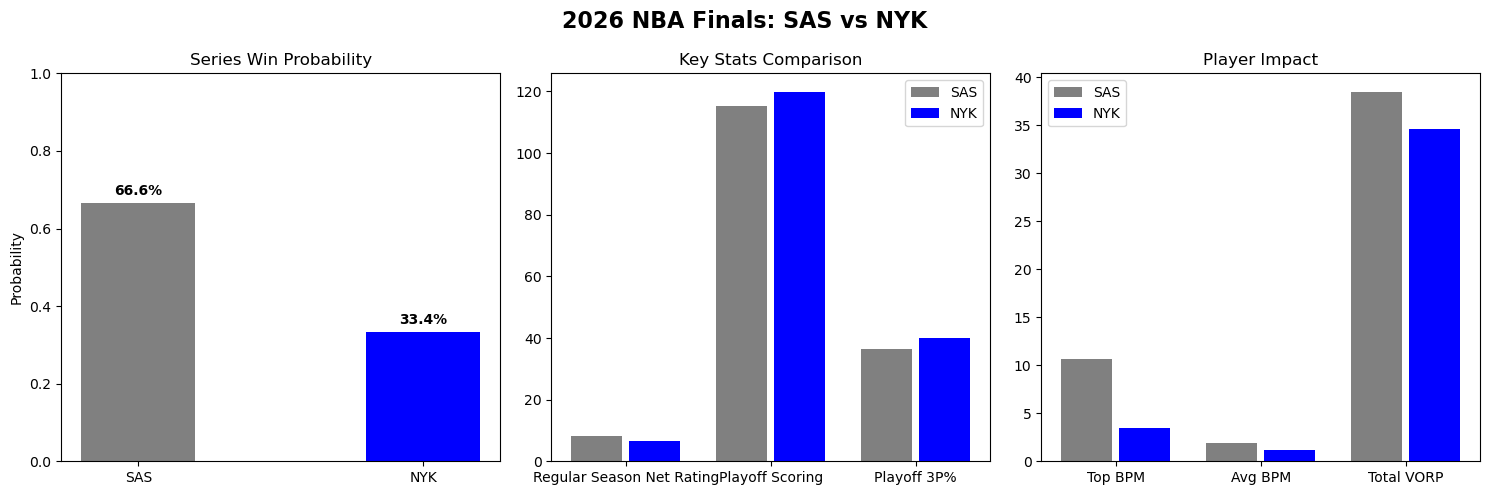

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('2026 NBA Finals: SAS vs NYK', fontsize=16, fontweight='bold')

# chart 1 - who wins the series
axes[0].bar(['SAS', 'NYK'], [sas_series_prob, nyk_series_prob], color=['gray', 'blue'], width=0.4)
axes[0].set_title('Series Win Probability')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 1)
for i, prob in enumerate([sas_series_prob, nyk_series_prob]):
    axes[0].text(i, prob + 0.02, str(round(prob * 100, 1)) + '%', ha='center', fontweight='bold')

# chart 2 - comparing some key stats between the two teams
categories = ['Regular Season Net Rating', 'Playoff Scoring', 'Playoff 3P%']
sas_vals = [sas['net_rtg'], sas['post_pts'], sas['post_3p_pct'] * 100]
nyk_vals = [nyk['net_rtg'], nyk['post_pts'], nyk['post_3p_pct'] * 100]

x = np.arange(len(categories))
axes[1].bar(x - 0.2, sas_vals, width=0.35, label='SAS', color='gray')
axes[1].bar(x + 0.2, nyk_vals, width=0.35, label='NYK', color='blue')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_title('Key Stats Comparison')
axes[1].legend()

# chart 3 - player impact, this is where SAS really pulls ahead
axes[2].bar(x - 0.2, [sas['top_bpm'], sas['avg_bpm'], sas['total_vorp']], width=0.35, label='SAS', color='gray')
axes[2].bar(x + 0.2, [nyk['top_bpm'], nyk['avg_bpm'], nyk['total_vorp']], width=0.35, label='NYK', color='blue')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Top BPM', 'Avg BPM', 'Total VORP'])
axes[2].set_title('Player Impact')
axes[2].legend()

plt.tight_layout()
plt.show()